In [73]:
import pandas as pd, numpy as np
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('physical_activity_data.csv') 
df

,Возраст,Шаги
0,63,7431.497886
1,20,10666.241856
2,46,5215.232170
3,52,9051.577199
4,56,7176.134884
...,...,...
195,63,7160.504053
196,41,11255.694260
197,43,9164.909848
198,45,8458.982247


In [5]:
data = pd.read_csv('hormone_levels_data.csv') 
data

,Возраст,Время_измерения,Уровень_гормона
0,48,11,68.891865
1,36,22,85.214371
2,48,11,63.668990
3,30,8,76.421995
4,21,15,45.136525
...,...,...,...
8395,39,13,65.088543
8396,46,18,69.867500
8397,31,18,60.446854
8398,39,11,72.237710


## Задача 1

Делим возраст на 4 группы по квартилям. Создаём категориальный признак age_group по заданным границам

In [40]:
edges1 = df['Возраст'].quantile([0, .25, .5, .75, 1.0]).to_numpy()
df['age_group'] = pd.cut(df['Возраст'], bins=edges1, include_lowest=True, labels=['G1','G2','G3','G4'])
labels = list(df['age_group'].cat.categories) 

агрегируем

In [41]:
n = len(df)                   # общий объём
k = len(labels)               # число групп (должно быть 4)
y = df['Шаги']
grand_mean = y.mean()
g = df.groupby('age_group')['Шаги']
nj = g.size().reindex(labels)               # размеры групп
means = g.mean().reindex(labels)            # средние по группам

/var/folders/0w/xxx48gr55csb_w73mfm7k80m0000gn/T/ipykernel_11264/3414188272.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby('age_group')['Шаги']


СПОСОБ 1 (через отклонения средних)

In [42]:
SS_BG_1 = float((nj * (means - grand_mean)**2).sum())  # между группами
SS_WG_1 = float(((y - df.groupby('age_group')['Шаги'].transform('mean'))**2).sum())  # внутри
SS_T_1  = float(((y - grand_mean)**2).sum())           # итого

/var/folders/0w/xxx48gr55csb_w73mfm7k80m0000gn/T/ipykernel_11264/2258012294.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  SS_WG_1 = float(((y - df.groupby('age_group')['Шаги'].transform('mean'))**2).sum())  # внутри


In [43]:
MS_BG_1 = SS_BG_1 / (k - 1)
MS_WG_1 = SS_WG_1 / (n - k)
F_1 = MS_BG_1 / MS_WG_1
p_1 = float(f.sf(F_1, k - 1, n - k))

anova_method_1 = pd.DataFrame({
    'SS':[SS_BG_1, SS_WG_1, SS_T_1],
    'df':[k-1, n-k, n-1],
    'MS':[MS_BG_1, MS_WG_1, np.nan],
    'F':[F_1, np.nan, np.nan],
    'p':[p_1, np.nan, np.nan]
}, index=['Between','Within','Total'])

СПОСОБ 2 (короткие формулы через суммы и суммы квадратов)

In [44]:
T_total = float(y.sum())                 # сумма по выборке
sum_x2  = float((y**2).sum())           # сумма квадратов по выборке
CF = T_total**2 / n                      # корректирующий член
SS_T_2 = sum_x2 - CF                     # общая сумма квадратов

Tj = g.sum().reindex(labels).fillna(0.0) # суммы по группам
nj2 = nj.fillna(0.0)                     # размеры по группам (float для деления)
SS_BG_2 = float(((Tj**2) / nj2.replace(0, np.nan)).sum() - CF)  # между группами
SS_WG_2 = SS_T_2 - SS_BG_2                                   # внутри

In [45]:
MS_BG_2 = SS_BG_2 / (k - 1)
MS_WG_2 = SS_WG_2 / (n - k)
F_2 = MS_BG_2 / MS_WG_2
p_2 = float(f.sf(F_2, k - 1, n - k))

anova_method_2 = pd.DataFrame({
    'SS':[SS_BG_2, SS_WG_2, SS_T_2],
    'df':[k-1, n-k, n-1],
    'MS':[MS_BG_2, MS_WG_2, np.nan],
    'F':[F_2, np.nan, np.nan],
    'p':[p_2, np.nan, np.nan]
}, index=['Between','Within','Total'])

финальный вывод чисел без принтов: границы групп, размеры групп, обе ANOVA-таблицы

In [49]:
edges1

array([18., 29., 41., 54., 65.])

Границы групп: [18–29], [29–41], [41–54], [54–65] лет.

размеры разниц:

In [47]:
nj

age_group
G1    54
G2    47
G3    50
G4    49
Name: Шаги, dtype: int64

In [56]:
anova_method_1.round(5)

,SS,df,MS,F,p
Between,4.689726e+08,3,1.563242e+08,46.80023,0.0
Within,6.546879e+08,196,3.340245e+06,NaN,NaN
Total,1.123661e+09,199,NaN,NaN,NaN


In [55]:
anova_method_2.round(5)

,SS,df,MS,F,p
Between,4.689726e+08,3,1.563242e+08,46.80023,0.0
Within,6.546879e+08,196,3.340245e+06,NaN,NaN
Total,1.123661e+09,199,NaN,NaN,NaN


#### Выводы

- среднее число шагов существенно различается между возрастными группами (нулевая гипотеза об одинаковых средних отвергается, p < 0.001)

- Значения увеличиваются с возрастом, что подтверждает возрастной эффект.

- Оба способа расчёта дали одинаковые результаты, что подтверждает корректность вычислений.

## Задача 2

In [57]:
data = data[(data['Время_измерения']>=6) & (data['Время_измерения']<=22)]

Возраст делим на 4 группы по квартилям

In [ ]:
age_edges  = data['Возраст'].quantile([0,.25,.5,.75,1]).to_numpy()
A_labels = ['A1','A2','A3','A4']

Время делим на 4 равных промежутка

In [59]:
time_edges = np.array([6,10,14,18,22])
T_labels = ['T1','T2','T3','T4']

In [60]:
data['age_group']  = pd.cut(data['Возраст'], bins=age_edges, include_lowest=True, labels=A_labels)
data['time_group'] = pd.cut(data['Время_измерения'], bins=time_edges, include_lowest=True, labels=T_labels)

Двухфакторный дисперсионный анализ

In [61]:
Y = data['Уровень_гормона']
grand_mean = Y.mean()

In [62]:
cell = data.groupby(['age_group','time_group'])['Уровень_гормона']
n_ij = cell.size().unstack().reindex(index=A_labels, columns=T_labels).fillna(0)
m_ij = cell.mean().unstack().reindex(index=A_labels, columns=T_labels).fillna(0)

/var/folders/0w/xxx48gr55csb_w73mfm7k80m0000gn/T/ipykernel_11264/1659481579.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell = data.groupby(['age_group','time_group'])['Уровень_гормона']


In [63]:
n_i = n_ij.sum(axis=1)
n_j = n_ij.sum(axis=0)
m_i = (m_ij.mul(n_ij)).sum(axis=1) / n_i.replace(0, np.nan)
m_j = (m_ij.mul(n_ij)).sum(axis=0) / n_j.replace(0, np.nan)

Суммы квадратов

In [64]:
SS_A  = float((n_i * (m_i - grand_mean)**2).sum())
SS_B  = float((n_j * (m_j - grand_mean)**2).sum())
SS_AB = float((n_ij * (m_ij.sub(m_i, axis=0).sub(m_j, axis=1) + grand_mean)**2).to_numpy().sum())

In [65]:
cell_mean_map = m_ij.stack().rename('cell_mean').reset_index()
tmp = data.merge(cell_mean_map, on=['age_group','time_group'], how='left')
SS_WG = float(((tmp['Уровень_гормона'] - tmp['cell_mean'])**2).sum())
SS_T  = float(((Y - grand_mean)**2).sum())

Степени свободы

In [66]:
a, b, N = len(A_labels), len(T_labels), len(data)
df_A, df_B, df_AB, df_WG = a-1, b-1, (a-1)*(b-1), N - a*b

Средние квадраты

In [67]:
MS_A, MS_B, MS_AB, MS_WG = SS_A/df_A, SS_B/df_B, SS_AB/df_AB, SS_WG/df_WG

F-критерии и p-значения

In [68]:
F_A, F_B, F_AB = MS_A/MS_WG, MS_B/MS_WG, MS_AB/MS_WG
p_A = float(f.sf(F_A, df_A, df_WG))
p_B = float(f.sf(F_B, df_B, df_WG))
p_AB = float(f.sf(F_AB, df_AB, df_WG))

Таблица ANOVA

In [72]:
anova = pd.DataFrame({
    'SS':[SS_A, SS_B, SS_AB, SS_WG, SS_T],
    'df':[df_A, df_B, df_AB, df_WG, N-1],
    'MS':[MS_A, MS_B, MS_AB, MS_WG, np.nan],
    'F' :[F_A, F_B, F_AB, np.nan, np.nan],
    'p' :[p_A, p_B, p_AB, np.nan, np.nan]
}, index=['Age','Time','Interaction','Within','Total'])

anova.round(5)

,SS,df,MS,F,p
Age,3.911993e+05,3,130399.76031,3303.86546,0.0
Time,3.301222e+05,3,110040.73123,2788.04018,0.0
Interaction,2.557239e+04,9,2841.37626,71.99035,0.0
Within,3.309068e+05,8384,39.46885,NaN,NaN
Total,1.078513e+06,8399,NaN,NaN,NaN


#### Выводы

- F = 3303.87, p = < 0.000001, значит возраст оказывает сильно статистически значимое влияние на уровень гормона в крови.

- F = 2788.04, p = < 0.000001, значит время суток также оказывает очень значимое влияние на уровень гормона.

- Взаимодействие (Interaction) тоже статистически значимо, значит, эффект времени суток на уровень гормона различается в зависимости от возраста.

- Возраст и время суток независимо и совместно влияют на уровень гормона.

Графики взаимодействия

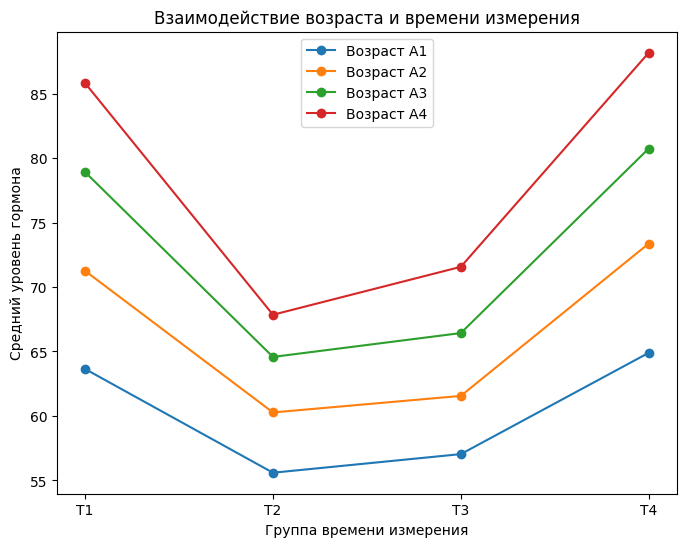

In [71]:
fig, ax = plt.subplots(figsize=(8,6))
for a_label in A_labels:
    means = m_ij.loc[a_label]
    ax.plot(T_labels, means, marker='o', label=f'Возраст {a_label}')
ax.set_xlabel("Группа времени измерения")
ax.set_ylabel("Средний уровень гормона")
ax.set_title("Взаимодействие возраста и времени измерения")
ax.legend()
plt.show()

- A1 (младшие): самые низкие уровни гормона по сравнению с другими.
- A2 и A3 (средние группы): уровень выше, но остаётся ниже, чем у самой старшей группы.
- A4 (старшие): самые высокие значения во все моменты времени.

- Линии не параллельные, значит взаимодействие есть (что подтвердил ANOVA)


- Разница между возрастами особенно велика утром (T1) и вечером (T4).
- В середине дня (T2–T3) кривые сближаются: различия по возрастам становятся меньше
- у всех групп есть суточный ритм с минимумом в T2 и максимумом в T4.
- это значит, что влияние времени суток на гормон разное у разных возрастов: у старших суточные колебания сглажены, у младших выражены сильнее.